# Self-training: pseudo-label weight versus confidence threshold

This notebook studies state-evolution trajectories over a grid of pseudo-label weights $\pi$ and confidence thresholds $\kappa$. It compares self-training, the supervised baseline ($\pi=0$), and a selected-label oracle. The oracle is a theorem-external counterfactual: it replaces pseudo-labels by true labels while preserving the same confidence selection rule.

All experiments use state evolution only: no finite design matrix is allocated and no finite-gradient trajectory is run. Run the notebook from top to bottom before presenting the figures.

In [154]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
from dataclasses import dataclass
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import expit, logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    get_s_mu,
    mahalanobis_separation,
    make_algorithm_config,
    run_experiment,
    run_state_evolution_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
)

## Experimental protocol

For every $(\kappa,\pi)$ pair, the arms use the same particle base law and random seed. The oracle modifies only the pseudo-label target in the selected unlabeled loss. We summarize each trajectory by $\mathcal{E}^\star=\min_{0\leq t\leq T}\mathcal{E}^t$ and its attaining iteration.

In [163]:
@dataclass(frozen=True)
class SweepParameters:
    seed: int
    n_iterations: int
    dimension: int
    delta: float
    label_prior: float
    supervision_ratio: float
    sigma: float
    signal_std: float
    signal_mean: float
    particle_count_w: int
    particle_count_g: int
    pseudo_label_weights: np.ndarray
    confidence_thresholds: np.ndarray
    step_size: float = 1.0
    penalty: float = 0.1


def run_state_evolution_sweep(p: SweepParameters) -> dict[str, np.ndarray]:
    """Run the three matched state-evolution arms on one parameter grid."""
    shape = (len(p.confidence_thresholds), len(p.pseudo_label_weights), p.n_iterations + 1)
    result = {name: np.empty(shape) for name in ("st", "sup", "oracle")}
    common = dict(
        d=p.dimension, delta=p.delta, n_test=200,  # API compatibility only
        label_prior=p.label_prior, rho=p.supervision_ratio, sigma=p.sigma,
        signal_std=p.signal_std, signal_mean=p.signal_mean,
        K_w=p.particle_count_w, K_g=p.particle_count_g, run_finite=False,
    )
    for i, kappa in enumerate(p.confidence_thresholds):
        supervised_config = make_algorithm_config(
            T=p.n_iterations, eta=p.step_size, penalty=p.penalty, pi=0.0, kappa=float(kappa)
        )
        supervised = run_experiment(
            name="supervised", algo_cfg=supervised_config, seed=p.seed, **common
        )
        supervised_error = state_evolution_state_observables(supervised)["error"]
        for j, pi in enumerate(p.pseudo_label_weights):
            st_config = make_algorithm_config(
                T=p.n_iterations, eta=p.step_size, penalty=p.penalty, pi=float(pi), kappa=float(kappa)
            )
            st = run_experiment(name="self-training", algo_cfg=st_config, seed=p.seed, **common)
            oracle = run_state_evolution_oracle_selected_label_counterfactual(st)
            result["st"][i, j] = state_evolution_state_observables(st)["error"]
            result["sup"][i, j] = supervised_error
            result["oracle"][i, j] = np.asarray(oracle.error, dtype=float)
    for name in ("st", "sup", "oracle"):
        result[f"{name}_min_error"] = np.min(result[name], axis=2)
        result[f"{name}_argmin_error"] = np.argmin(result[name], axis=2)
    return result


def plot_summary_heatmaps(result, p, include_oracle_panels = True):
    """Display the original best-over-time summary matrices."""
    st_min, sup_min, oracle_min = (result[f"{name}_min_error"] for name in ("st", "sup", "oracle"))
    panels = [
        (st_min, r"$\min_{0 \leq t \leq T}\mathcal{E}^t_{ST}$", "viridis", False, True),
        (result["st_argmin_error"], r"$\operatorname{argmin}_{0 \leq t \leq T}\mathcal{E}^t_{ST}$", "viridis", False, False),
    ]
    if include_oracle_panels:
        captured_gain = (sup_min - st_min) / (sup_min - oracle_min)
        panels += [
            (oracle_min, r"$\min_{0 \leq t \leq T}\mathcal{E}^t_{oracle}$", "viridis", False, True),
            (captured_gain, r"$(\mathcal{E}^\star_{sup}-\mathcal{E}^\star_{ST})/(\mathcal{E}^\star_{sup}-\mathcal{E}^\star_{oracle})$", "viridis", False, True),
        ]
    panels += [
        (st_min - sup_min, r"$\mathcal{E}^\star_{ST}-\mathcal{E}^\star_{sup}$", "coolwarm", True, True),
        (st_min - oracle_min, r"$\mathcal{E}^\star_{ST}-\mathcal{E}^\star_{oracle}$", "coolwarm", True, True),
    ]
    n_rows = 3 if include_oracle_panels else 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows), constrained_layout=True)
    kappa_labels = [f"logit({expit(k):.2f})" for k in p.confidence_thresholds]
    pi_labels = [f"{pi:.1f}" for pi in p.pseudo_label_weights]
    for axis, (matrix, title, cmap, signed, decimal) in zip(axes.flat, panels):
        limit = np.max(np.abs(matrix)) if signed else None
        image = axis.imshow(matrix, aspect="auto", origin="lower", cmap=cmap,
                            vmin=-limit if signed else None, vmax=limit if signed else None)
        axis.set(xticks=np.arange(len(pi_labels)), xticklabels=pi_labels, xlabel=r"Pseudo-label weight $\pi$",
                 yticks=np.arange(len(kappa_labels)), yticklabels=kappa_labels,
                 ylabel=r"Selection threshold $\kappa$", title=title)
        for row in range(matrix.shape[0]):
            for column in range(matrix.shape[1]):
                text = f"{matrix[row, column]:.2f}" if decimal else f"{matrix[row, column]:.0f}"
                axis.text(column, row, text, ha="center", va="center", fontsize=7)
        fig.colorbar(image, ax=axis)
    plt.show()


def plot_trajectory(result, p, index, *, include_oracle=True):
    """Plot one pre-specified $(\kappa,\pi)$ trajectory comparison."""
    i, j = index
    plt.plot(result["st"][index], label="self-training")
    plt.plot(result["sup"][index], label="supervised")
    if include_oracle:
        plt.plot(result["oracle"][index], label="oracle selected labels")
    plt.title(rf"$\kappa={expit(p.confidence_thresholds[i]):.2f},\;\pi={p.pseudo_label_weights[j]:.1f}$")
    plt.xlabel("iteration")
    plt.ylabel(r"population error $\mathcal{E}^t$")
    plt.grid()
    plt.legend()
    plt.show()

## Broad sweep

Here $\mu_j\sim\mathcal N(1/\sqrt 2,1/2)$, $\sigma=1$, $d=1$, $\delta=20$, and $\rho=0.01$. The grid ranges from low to high confidence and pseudo-label weights.

In [157]:
broad_parameters = SweepParameters(
    seed=4100, n_iterations=100, dimension=1, delta=20.0, label_prior=0.5,
    supervision_ratio=0.01, sigma=1.0, signal_std=0.5**0.5, signal_mean=0.5**0.5,
    particle_count_w=4_000, particle_count_g=4_800,
    pseudo_label_weights=np.array([0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]),
    confidence_thresholds=logit(np.array([0.5, 0.7, 0.8, 0.9, 0.95, 0.975, 0.99])),
)
broad_results = run_state_evolution_sweep(broad_parameters)
print(f"Mahalanobis separation: {mahalanobis_separation(get_s_mu(broad_parameters.signal_mean, broad_parameters.signal_std), broad_parameters.sigma):.3f}")

Mahalanobis separation: 2.000


/var/folders/1v/q141c9gj6fxf_hkyjl6w9y8c0000gn/T/ipykernel_22596/1741193967.py:61: RuntimeWarning: invalid value encountered in divide
  captured_gain = (sup_min - st_min) / (sup_min - oracle_min)


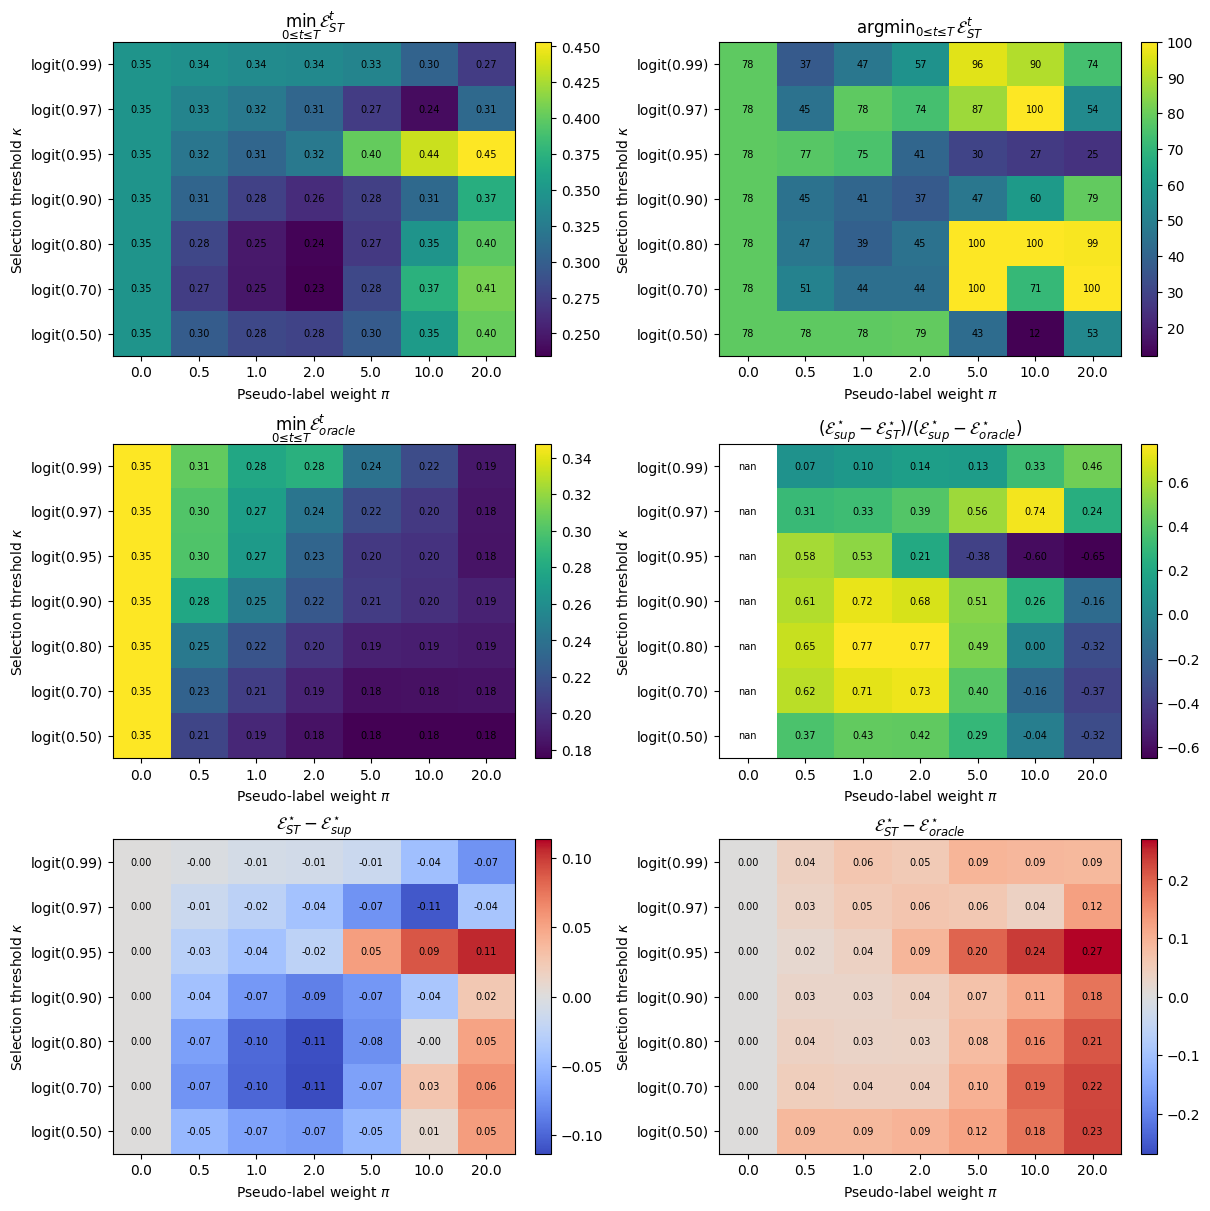

In [165]:
plot_summary_heatmaps(broad_results, broad_parameters, include_oracle_panels=True)

### Representative trajectories

These are the same three grid locations displayed in the original broad sweep. 

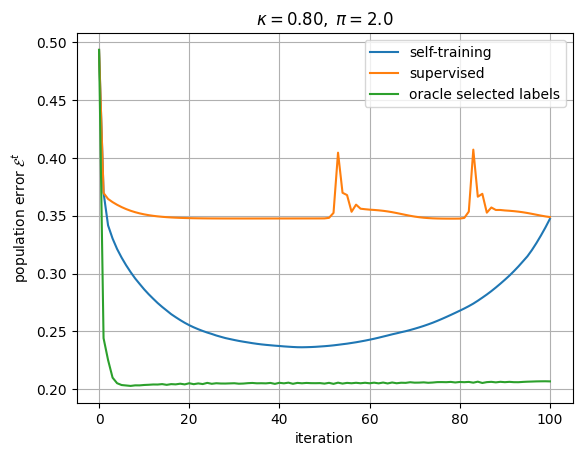

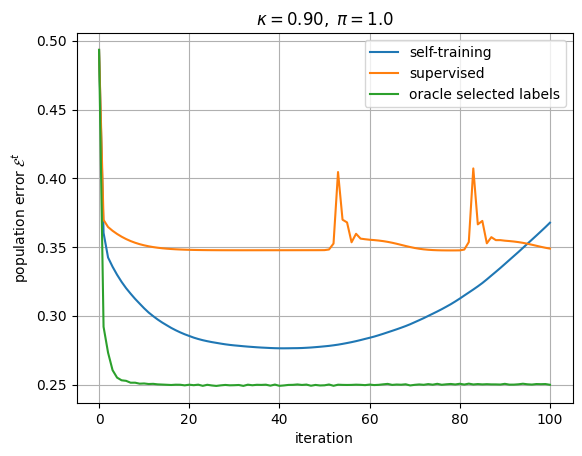

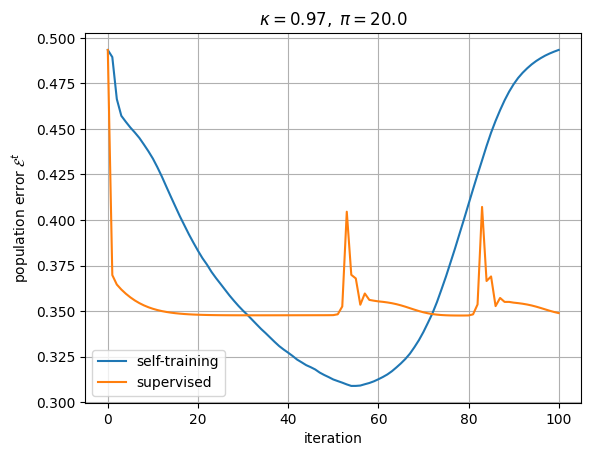

In [174]:
plot_trajectory(broad_results, broad_parameters, (2, 3))
plot_trajectory(broad_results, broad_parameters, (3, 2))
plot_trajectory(broad_results, broad_parameters, (5, 6), include_oracle=False)

### Remark
The sudden jumps observed in the supervised state-evolution trajectory are numerical rather than intrinsic to the limiting dynamics. After a small number of iterations, the supervised iterates become stationary, so successive trajectory vectors are almost linearly dependent. As a result, the associated trajectory Gram matrices become ill-conditioned, and the computation of the corresponding projection coefficients becomes numerically unstable. This loss of numerical precision can produce the apparent jumps observed in the state-evolution outputs.

### Separation observation

Empirically, the Mahalanobis separation largely dictates overall performance. Running the same experiment with $\operatorname{Mean}(\mu)=0$, $\operatorname{Std}(\mu)=1$, $\sigma=1$, and $\delta=20$ yields identical results.

## Focused high-confidence sweep

We refine the threshold grid near $0.9$-$0.98$ and retain only larger pseudo-label weights. The larger particle budgets reduce Monte Carlo variability in this more sensitive regime.

In [158]:
focused_parameters = SweepParameters(
    seed=4100, n_iterations=100, dimension=1, delta=20.0, label_prior=0.5,
    supervision_ratio=0.01, sigma=1.0, signal_std=0.5**0.5, signal_mean=0.5**0.5,
    particle_count_w=13_000, particle_count_g=16_000,
    pseudo_label_weights=np.array([5.0, 10.0, 20.0]),
    confidence_thresholds=logit(np.array([0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98])),
)
focused_results = run_state_evolution_sweep(focused_parameters)

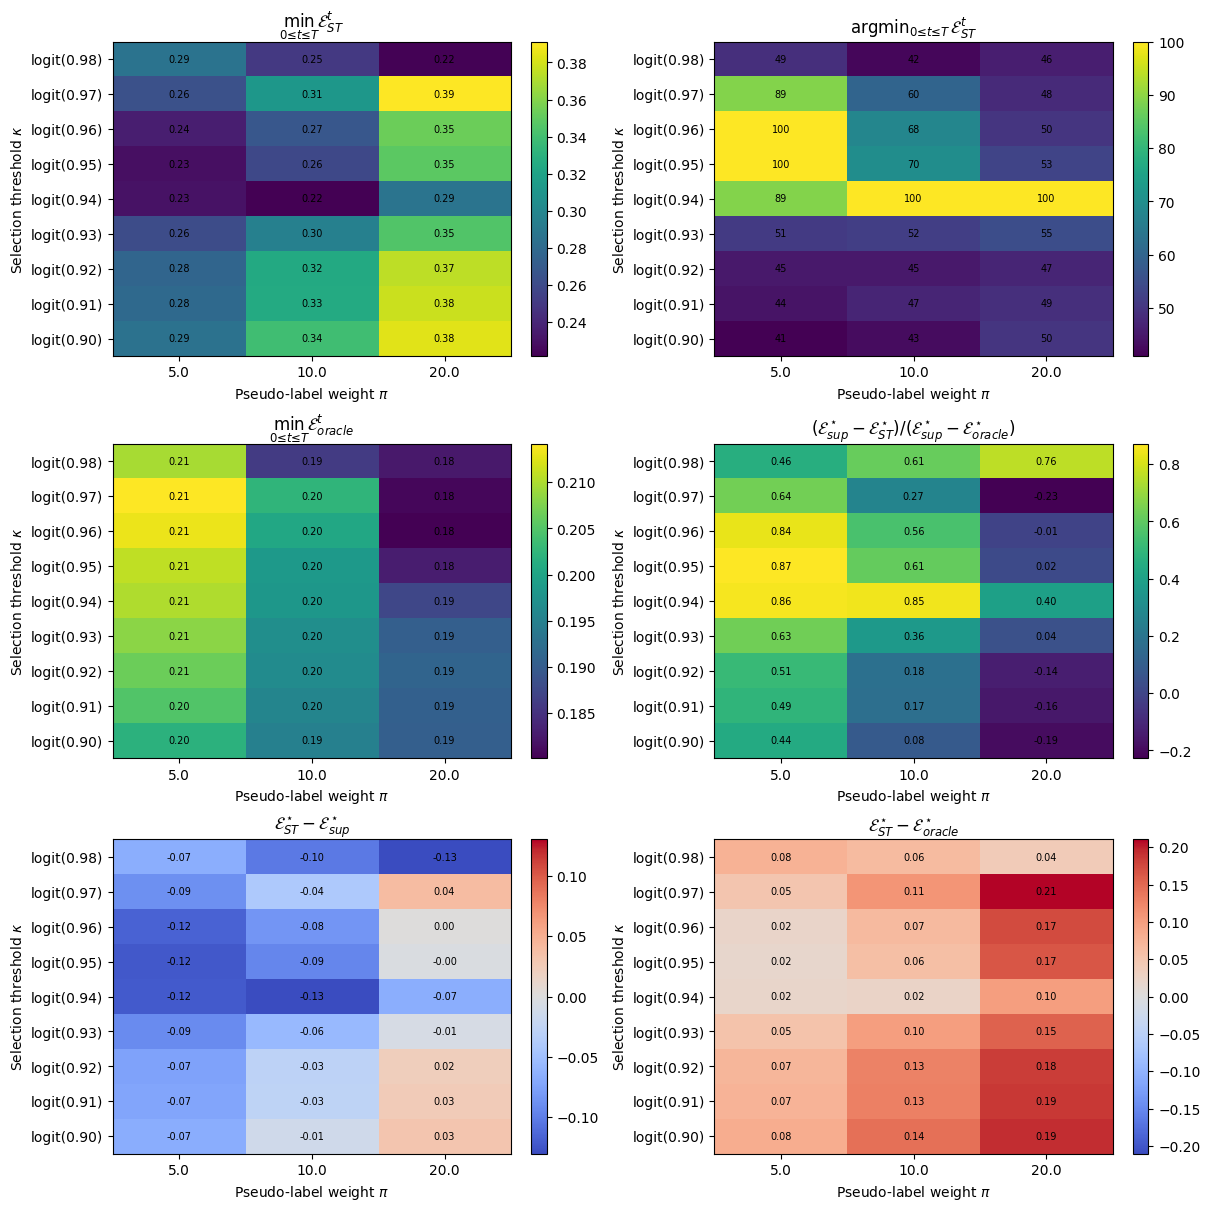

In [171]:
plot_summary_heatmaps(focused_results, focused_parameters)

### Focused trajectory comparisons

The selected points correspond to $\kappa=0.90$, $0.92$, and $0.94$ with $\pi=5$.

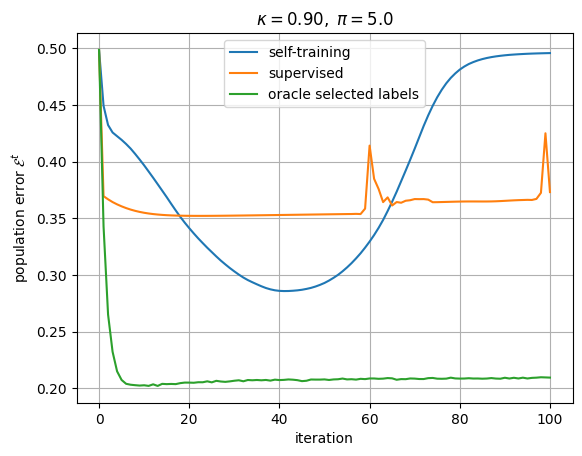

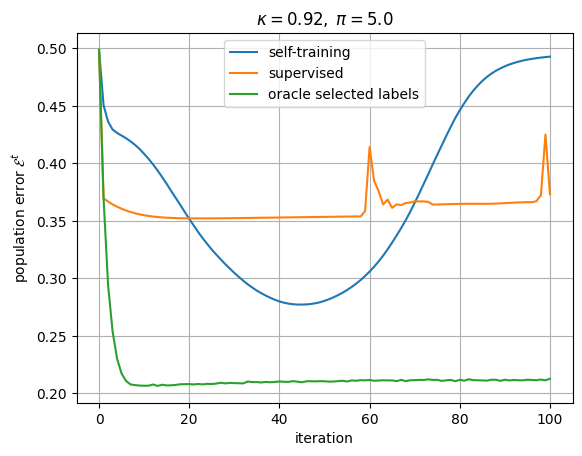

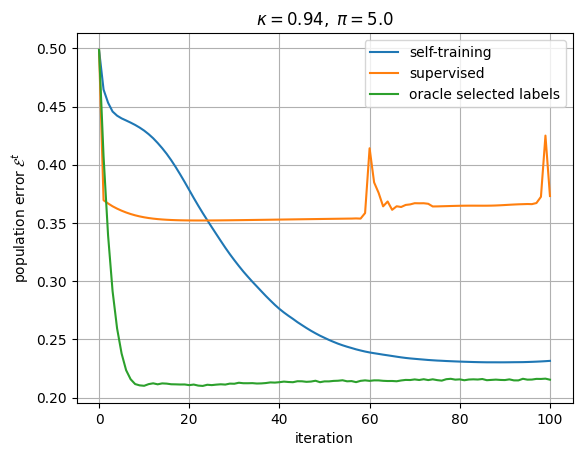

In [172]:
plot_trajectory(focused_results, focused_parameters, (0, 0))
plot_trajectory(focused_results, focused_parameters, (2, 0))
plot_trajectory(focused_results, focused_parameters, (4, 0))

## Takeaways

The oracle estimator varies little across $\kappa$ but substantially across $\pi$. In contrast, self-training is highly sensitive to $\kappa$. Good self-training performance occurs when its gap to the selected-label oracle is small.

Thus, the useful information available to the oracle changes little with $\kappa$, whereas pseudo-labeling's ability to exploit that information changes markedly with $\kappa$. Larger pseudo-label weights offer more potential gain, but require tighter control of confirmation errors.